# Cookie Cats A/B Test Analysis

**Dataset:** [Cookie Cats A/B Testing](https://www.kaggle.com/datasets/mursideyarkin/mobile-games-ab-testing-cookie-cats) â Kaggle

This is real experimental data from **Tactile Entertainment**, the studio behind the mobile puzzle game *Cookie Cats*. In the game, players hit "gates" that force a wait (or an in-app purchase) before continuing. The experiment tested moving the first gate from **level 30** to **level 40**, to see the effect on player retention and engagement. Sample size is ~90,000 players.

- `version = gate_30` → control group (gate at level 30, the original placement)
- `version = gate_40` → treatment group (gate moved to level 40)

---

## Phase 1 Scope

This notebook section covers **data loading, inspection, and quality checks only**. No hypothesis testing on retention and no business conclusions are made here — that is reserved for later sections. The one exception is a **Sample Ratio Mismatch (SRM) check**, which is a data-validity sanity check (confirming randomization worked as intended), not the core experiment analysis.

**Sections in this notebook:**
1. Load & inspect the dataset
2. Column-by-column explanation
3. Data quality checks (shape, dtypes, missing values, duplicates)
4. Experiment group sizes
5. Sample Ratio Mismatch (SRM) check
6. Exploratory summaries of each variable

In [1]:
# Core libraries for data handling, stats, and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Display / plotting settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

RANDOM_SEED = 42

## 1. Load & Inspect the Dataset

In [2]:
# Raw data lives untouched in data/raw/ â we read directly from the source file
DATA_PATH = '../data/raw/cookie_cats.csv'

df = pd.read_csv(DATA_PATH)

print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head(10)

Rows: 90,189  |  Columns: 5


,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
5,540,gate_40,187,True,True
6,1066,gate_30,0,False,False
7,1444,gate_40,2,False,False
8,1574,gate_40,108,True,True
9,1587,gate_40,153,True,False


In [3]:
df.tail(5)

,userid,version,sum_gamerounds,retention_1,retention_7
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False
90188,9999861,gate_40,16,False,False


## 2. Column-by-Column Explanation

| Column | Type | Description |
|---|---|---|
| `userid` | integer | Unique identifier for each player. One row per player — this is the experimental unit. |
| `version` | categorical (string) | Which A/B arm the player was assigned to: `gate_30` (control, gate at level 30) or `gate_40` (treatment, gate at level 40). |
| `sum_gamerounds` | integer | Total number of game rounds the player completed in the first 14 days after install. Our engagement / guardrail metric. |
| `retention_1` | boolean | Whether the player came back and played the game 1 day after installing. Primary short-term retention metric. |
| `retention_7` | boolean | Whether the player came back and played the game 7 days after installing. Primary long-term retention metric. |

**Notes on interpretation:**
- `retention_1` and `retention_7` are independent flags — a player can be `retention_7 = True` while `retention_1 = False` (e.g., they skipped day 1 but returned by day 7), so the two columns are not a strict funnel.
- `sum_gamerounds = 0` is a valid value: it means the player installed the game but never actually played a round.

## 3. Data Quality Checks

### 3.1 Shape and Data Types

In [4]:
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns\n')
df.info()

Shape: 90,189 rows x 5 columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


`retention_1` and `retention_7` load as native booleans, `sum_gamerounds` and `userid` as integers, and `version` as an object (string) — these are the expected dtypes for this dataset, so no type coercion is needed.

### 3.2 Missing Values

In [5]:
missing = pd.DataFrame({
    'missing_count': df.isnull().sum(),
    'missing_pct': (df.isnull().mean() * 100).round(3)
})
missing

,missing_count,missing_pct
userid,0,0.0000
version,0,0.0000
sum_gamerounds,0,0.0000
retention_1,0,0.0000
retention_7,0,0.0000


In [6]:
total_missing = df.isnull().sum().sum()
if total_missing == 0:
    print('No missing values found anywhere in the dataset. No imputation or dropna() needed.')
else:
    print(f'{total_missing} missing values found â see breakdown above.')

No missing values found anywhere in the dataset. No imputation or dropna() needed.


### 3.3 Duplicate User IDs

Each `userid` should appear exactly once, since a row represents one player's full experiment record.

In [7]:
n_rows = len(df)
n_unique_users = df['userid'].nunique()
n_duplicate_userids = df['userid'].duplicated().sum()
n_fully_duplicate_rows = df.duplicated().sum()

print(f'Total rows:                {n_rows:,}')
print(f'Unique userids:            {n_unique_users:,}')
print(f'Duplicated userid rows:    {n_duplicate_userids:,}')
print(f'Fully duplicate rows:      {n_fully_duplicate_rows:,}')

assert n_rows == n_unique_users, 'userid is not unique per row — investigate before proceeding.'
print('\nConfirmed: userid is unique per row. Each player appears exactly once.')

Total rows:                90,189
Unique userids:            90,189
Duplicated userid rows:    0
Fully duplicate rows:      0

Confirmed: userid is unique per row. Each player appears exactly once.


### 3.4 Value Sanity Checks

Quick checks that categorical/boolean columns only contain expected values, and that `sum_gamerounds` has no impossible (negative) values.

In [8]:
print('Unique values in `version`:', df['version'].unique().tolist())
print('Unique values in `retention_1`:', df['retention_1'].unique().tolist())
print('Unique values in `retention_7`:', df['retention_7'].unique().tolist())
print('Min `sum_gamerounds`:', df['sum_gamerounds'].min())
print('Max `sum_gamerounds`:', df['sum_gamerounds'].max())
print('Negative sum_gamerounds count:', (df['sum_gamerounds'] < 0).sum())

Unique values in `version`: ['gate_30', 'gate_40']
Unique values in `retention_1`: [False, True]
Unique values in `retention_7`: [False, True]
Min `sum_gamerounds`: 0
Max `sum_gamerounds`: 49854
Negative sum_gamerounds count: 0


The `version` and retention columns only contain the expected categories, and `sum_gamerounds` has no negative values, which is what we'd expect from a rounds-played counter. The maximum value is flagged and examined further in the outlier check (Section 6.2) — it is far outside the typical range and is noted as a data quality observation, not acted on here.

## 4. Experiment Group Sizes

In [9]:
group_counts = df['version'].value_counts().rename('n_players').to_frame()
group_counts['pct_of_total'] = (group_counts['n_players'] / len(df) * 100).round(2)
group_counts

,n_players,pct_of_total
version,,
gate_40,45489,50.4400
gate_30,44700,49.5600


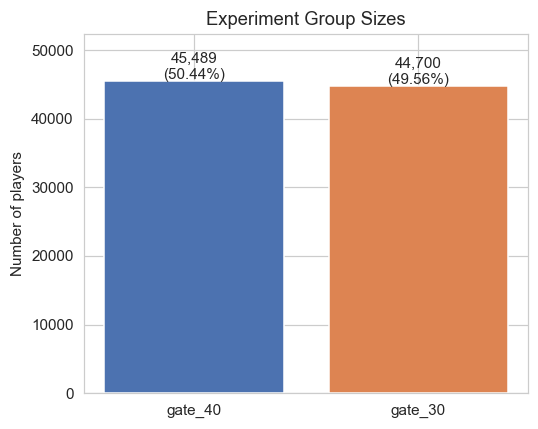

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
colors = ['#4C72B0', '#DD8452']
ax.bar(group_counts.index, group_counts['n_players'], color=colors)
for i, (idx, row) in enumerate(group_counts.iterrows()):
    ax.text(i, row['n_players'] + 300, f"{int(row['n_players']):,}\n({row['pct_of_total']}%)",
            ha='center', fontsize=10)
ax.set_ylabel('Number of players')
ax.set_title('Experiment Group Sizes')
ax.set_ylim(0, group_counts['n_players'].max() * 1.15)
plt.tight_layout()
plt.show()

## 5. Sample Ratio Mismatch (SRM) Check

Before trusting any downstream comparison between groups, we confirm the randomization split is close to the intended ratio (50/50). This is purely a **data-validity check**: if group sizes are meaningfully skewed from what was intended, it signals a bug in the randomization/logging pipeline and would invalidate any later comparison — regardless of what that comparison shows. This is *not* the retention hypothesis test itself, which is deferred to a later phase.

In [11]:
observed = group_counts['n_players'].values
n_total = observed.sum()
expected_ratio = np.array([0.5, 0.5])  # intended 50/50 split
expected = expected_ratio * n_total

chi2_stat, srm_p_value = stats.chisquare(f_obs=observed, f_exp=expected)

print(f'Observed counts : {observed[0]:,} vs {observed[1]:,}')
print(f'Expected counts : {expected[0]:,.1f} vs {expected[1]:,.1f}')
print(f'Observed ratio  : {observed[0] / n_total:.4f} / {observed[1] / n_total:.4f}')
print(f'Chi-square stat : {chi2_stat:.4f}')
print(f'p-value         : {srm_p_value:.4f}')

Observed counts : 45,489 vs 44,700
Expected counts : 45,094.5 vs 45,094.5
Observed ratio  : 0.5044 / 0.4956
Chi-square stat : 6.9024
p-value         : 0.0086


In [12]:
# Standard SRM convention: flag if p < 0.01 (stricter threshold than typical alpha=0.05,
# since SRM checks are a pass/fail gate on data integrity, not the experiment result itself)
SRM_THRESHOLD = 0.01

if srm_p_value < SRM_THRESHOLD:
    print(f'p-value ({srm_p_value:.4f}) < {SRM_THRESHOLD} — SRM DETECTED. Group sizes deviate from the expected split;'
          ' downstream results would need to be treated with caution.')
else:
    print(f'p-value ({srm_p_value:.4f}) >= {SRM_THRESHOLD} — No Sample Ratio Mismatch detected.')
    print('Group sizes are consistent with the intended 50/50 random assignment.')

p-value (0.0086) < 0.01 — SRM DETECTED. Group sizes deviate from the expected split; downstream results would need to be treated with caution.


## 6. Exploratory Summaries of Variables

Descriptive only — no significance testing and no claims about which group performs better. The goal here is purely to understand each variable's distribution before any formal comparison.

### 6.1 `sum_gamerounds` — Overall Distribution

In [13]:
df['sum_gamerounds'].describe(percentiles=[.25, .5, .75, .9, .99])

count   90,189.0000
mean        51.8725
std        195.0509
min          0.0000
25%          5.0000
50%         16.0000
75%         51.0000
90%        134.0000
99%        493.0000
max     49,854.0000
Name: sum_gamerounds, dtype: float64

### 6.2 Outlier Observation

The maximum value identified in Section 3.4 is far beyond the 99th percentile. We look at it directly rather than removing it — the raw data stays untouched at this stage.

In [14]:
top_5_rounds = df.nlargest(5, 'sum_gamerounds')[['userid', 'version', 'sum_gamerounds', 'retention_1', 'retention_7']]
top_5_rounds

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True
7912,871500,gate_30,2961,True,True
29417,3271615,gate_40,2640,True,False
43671,4832608,gate_30,2438,True,True
48188,5346171,gate_40,2294,True,True


This single extreme value (far above the next-highest player) is noted here as a data quality observation for later phases to decide how to handle (e.g., capping, exclusion criteria, or robust statistics) — no decision is made in this notebook section.

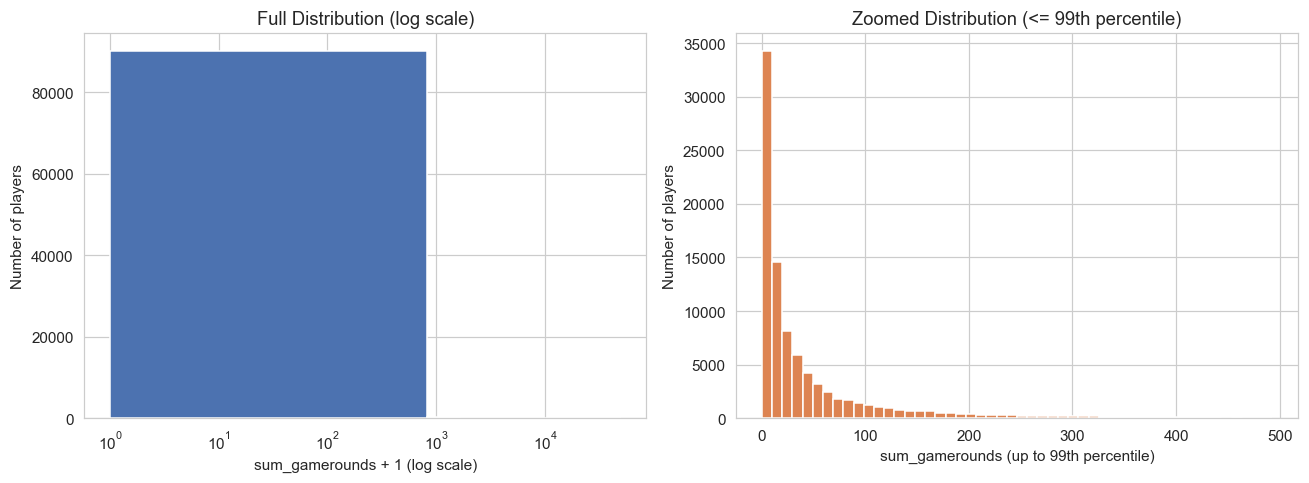

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Full distribution (log scale on x since it's heavily right-skewed)
axes[0].hist(df['sum_gamerounds'] + 1, bins=60, color='#4C72B0', edgecolor='white')
axes[0].set_xscale('log')
axes[0].set_xlabel('sum_gamerounds + 1 (log scale)')
axes[0].set_ylabel('Number of players')
axes[0].set_title('Full Distribution (log scale)')

# Zoomed view, excluding the top 1% so the bulk of the distribution is visible
p99 = df['sum_gamerounds'].quantile(0.99)
zoomed = df.loc[df['sum_gamerounds'] <= p99, 'sum_gamerounds']
axes[1].hist(zoomed, bins=50, color='#DD8452', edgecolor='white')
axes[1].set_xlabel('sum_gamerounds (up to 99th percentile)')
axes[1].set_ylabel('Number of players')
axes[1].set_title('Zoomed Distribution (<= 99th percentile)')

plt.tight_layout()
plt.show()

`sum_gamerounds` is heavily right-skewed: most players play relatively few rounds, a long tail plays a lot, and a small number of players never play a single round at all.

In [16]:
zero_rounds_pct = (df['sum_gamerounds'] == 0).mean() * 100
print(f"Players with sum_gamerounds == 0 (installed but never played a round): {zero_rounds_pct:.2f}%")

Players with sum_gamerounds == 0 (installed but never played a round): 4.43%


### 6.3 `sum_gamerounds` by Group (Descriptive Only)

Side-by-side descriptive statistics per group. This is *not* a guardrail-metric hypothesis test — that comparison, with proper statistical treatment of the skew and the outlier, belongs in a later phase.

In [17]:
df.groupby('version')['sum_gamerounds'].describe(percentiles=[.5, .9, .99]).T

version,gate_30,gate_40
count,"44,700.0000","45,489.0000"
mean,52.4563,51.2988
std,256.7164,103.2944
min,0.0000,0.0000
50%,17.0000,16.0000
90%,135.0000,134.0000
99%,493.0000,492.1200
max,"49,854.0000","2,640.0000"


### 6.4 `retention_1` and `retention_7` — Raw Rates

Raw observed proportions only — no confidence intervals or significance test yet. These are purely descriptive counts to understand the variables before formal analysis.

In [18]:
retention_summary = df.groupby('version')[['retention_1', 'retention_7']].mean().rename(
    columns={'retention_1': 'retention_1_rate', 'retention_7': 'retention_7_rate'}
)
retention_summary['n_players'] = df.groupby('version').size()
retention_summary

,retention_1_rate,retention_7_rate,n_players
version,,,
gate_30,0.4482,0.1902,44700
gate_40,0.4423,0.1820,45489


In [19]:
print('Overall retention_1 rate:', f"{df['retention_1'].mean():.4f}")
print('Overall retention_7 rate:', f"{df['retention_7'].mean():.4f}")
print()
print('retention_1 & retention_7 cross-tab (raw counts):')
pd.crosstab(df['retention_1'], df['retention_7'], margins=True, margins_name='Total')

Overall retention_1 rate: 0.4452
Overall retention_7 rate: 0.1861

retention_1 & retention_7 cross-tab (raw counts):


retention_7,False,True,Total
retention_1,,,
False,46437,3599,50036
True,26971,13182,40153
Total,73408,16781,90189


The cross-tab confirms `retention_1` and `retention_7` are related but not a strict funnel: some players return on day 7 without having returned on day 1.

### 6.5 `version` — Categorical Summary

In [20]:
df['version'].value_counts(normalize=True).rename('proportion').to_frame()

,proportion
version,
gate_40,0.5044
gate_30,0.4956


## Phase 1 Summary

- Dataset loads cleanly: **90,189 rows, 5 columns**, one row per player.
- No missing values in any column.
- `userid` is unique per row — no duplicate players.
- All categorical/boolean columns contain only expected values; `sum_gamerounds` has no negative values.
- Group sizes are close to, but not exactly, a 50/50 split (49.6% gate_30 / 50.4% gate_40). The SRM chi-square check returned **p = 0.0086**, just under the conventional p < 0.01 SRM threshold — a borderline signal worth flagging as a caveat for downstream comparisons, though the absolute imbalance is small (~789 players, <1% of the sample).
- `sum_gamerounds` is heavily right-skewed with one extreme outlier flagged for handling in a later phase.
- `retention_1` and `retention_7` raw rates and the `version` split have been profiled descriptively only — no statistical testing or business conclusions have been drawn.

**Next phase:** formal hypothesis testing on `retention_1` / `retention_7` (proportion z-test / chi-square with effect size and CI), reverse power analysis (MDE), guardrail metric testing on `sum_gamerounds`, segment cuts, and design critique. The borderline SRM result noted above should be revisited when interpreting those results.

# Phase 2: Core Hypothesis Test — Does Moving the Gate Affect Retention?

## Business Question

Tactile Entertainment moved the first progression gate in *Cookie Cats* from **level 30** to **level 40**. The business question this experiment is meant to answer:

> **Does moving the gate later in the game change how many players come back to play?**

Retention is the metric of interest because it is a leading indicator of long-term player base health and, downstream, monetization opportunity. We evaluate this using the two retention flags in the dataset:

- **`retention_1`** — did the player return 1 day after install?
- **`retention_7`** — did the player return 7 days after install?

## Hypotheses

For each retention metric, we test the null hypothesis that gate placement has no effect on the population retention rate, against a two-sided alternative. We do not assume a direction a priori — moving the gate later could plausibly *help* retention (delaying the friction point) or *hurt* it (letting players build more habit/progress before hitting a wall, then losing more of them there):

**Day-1 retention**
- H₀: p(retention_1 | gate_30) = p(retention_1 | gate_40)
- H₁: p(retention_1 | gate_30) ≠ p(retention_1 | gate_40)

**Day-7 retention**
- H₀: p(retention_7 | gate_30) = p(retention_7 | gate_40)
- H₁: p(retention_7 | gate_30) ≠ p(retention_7 | gate_40)

Both tests are run at **α = 0.05**, two-sided.

## Carrying Forward the Phase 1 Caveat

Phase 1's SRM check found a borderline imbalance in group sizes (χ² p = 0.0086, just under the 0.01 SRM threshold). This does not invalidate the tests below, but it means any statistically significant result here should be interpreted with some caution about whether the imbalance reflects a subtle issue in random assignment. We return to this point in the interpretation section.

In [21]:
# Statistical tools for two-sample proportion testing
from statsmodels.stats.proportion import proportions_ztest, proportion_confint, confint_proportions_2indep
from scipy.stats import chi2_contingency

CONTROL = 'gate_30'
TREATMENT = 'gate_40'
ALPHA = 0.05

## 2.1 Day-1 Retention (`retention_1`)

**Methodology:** for each metric we compute, using a two-sided two-proportion z-test (equivalent to an uncorrected chi-square test of independence on a 2x2 table):

- Retention rate per group
- Absolute difference (treatment − control) and relative difference (% change vs. control)
- 95% confidence interval for the difference in proportions, using the **Newcombe score interval** (more reliable than the Wald interval for proportions, especially near 0 or 1)
- z-statistic and two-sided p-value
- **Cohen's h**, the standard effect size measure for the difference between two proportions

A chi-square test is run alongside the z-test as a cross-check — for a 2×2 table without continuity correction, χ² = z², so the two should agree.

In [22]:
def two_proportion_test(data, metric, control=CONTROL, treatment=TREATMENT, alpha=ALPHA):
    """Two-proportion z-test + 95% CI (Newcombe) + effect size for a binary outcome, control vs. treatment."""
    successes = data.groupby('version')[metric].sum()
    nobs = data.groupby('version').size()

    count = np.array([successes[control], successes[treatment]])
    n = np.array([nobs[control], nobs[treatment]])

    p_control = count[0] / n[0]
    p_treatment = count[1] / n[1]

    z_stat, p_value = proportions_ztest(count, n, alternative='two-sided')

    # Newcombe score interval for the difference (treatment - control)
    ci_low, ci_high = confint_proportions_2indep(
        count[1], n[1], count[0], n[0], method='newcomb', compare='diff', alpha=alpha
    )

    abs_diff = p_treatment - p_control
    rel_diff_pct = (abs_diff / p_control) * 100

    # Cohen's h: standard effect size for the difference between two proportions
    cohens_h = 2 * np.arcsin(np.sqrt(p_treatment)) - 2 * np.arcsin(np.sqrt(p_control))

    # Chi-square cross-check (uncorrected, 2x2 table) -- chi2_stat should equal z_stat**2
    contingency = np.array([
        [count[0], n[0] - count[0]],
        [count[1], n[1] - count[1]],
    ])
    chi2_stat, chi2_p, _, _ = chi2_contingency(contingency, correction=False)

    return {
        'metric': metric,
        'n_control': n[0], 'n_treatment': n[1],
        'rate_control': p_control, 'rate_treatment': p_treatment,
        'abs_diff': abs_diff, 'rel_diff_pct': rel_diff_pct,
        'ci_diff_low': ci_low, 'ci_diff_high': ci_high,
        'z_stat': z_stat, 'p_value': p_value,
        'cohens_h': cohens_h,
        'chi2_stat': chi2_stat, 'chi2_p': chi2_p,
    }


def print_result(res):
    print(f"Metric: {res['metric']}")
    print(f"  n ({CONTROL} / {TREATMENT}):        {res['n_control']:,} / {res['n_treatment']:,}")
    print(f"  Retention rate {CONTROL}:      {res['rate_control']:.4f}")
    print(f"  Retention rate {TREATMENT}:      {res['rate_treatment']:.4f}")
    print(f"  Absolute difference (treatment - control): {res['abs_diff']:+.4f}")
    print(f"  Relative difference vs. control:           {res['rel_diff_pct']:+.2f}%")
    print(f"  95% CI for difference (Newcombe):          [{res['ci_diff_low']:+.4f}, {res['ci_diff_high']:+.4f}]")
    print(f"  z-statistic: {res['z_stat']:.4f}   p-value: {res['p_value']:.6f}")
    print(f"  Chi-square:  {res['chi2_stat']:.4f}   p-value: {res['chi2_p']:.6f}  (cross-check, should equal z^2)")
    print(f"  Cohen's h (effect size): {res['cohens_h']:.4f}")


result_r1 = two_proportion_test(df, 'retention_1')
print_result(result_r1)

Metric: retention_1
  n (gate_30 / gate_40):        44,700 / 45,489
  Retention rate gate_30:      0.4482
  Retention rate gate_40:      0.4423
  Absolute difference (treatment - control): -0.0059
  Relative difference vs. control:           -1.32%
  95% CI for difference (Newcombe):          [-0.0124, +0.0006]
  z-statistic: 1.7841   p-value: 0.074410
  Chi-square:  3.1830   p-value: 0.074410  (cross-check, should equal z^2)
  Cohen's h (effect size): -0.0119


## 2.2 Day-7 Retention (`retention_7`)

In [23]:
result_r7 = two_proportion_test(df, 'retention_7')
print_result(result_r7)

Metric: retention_7
  n (gate_30 / gate_40):        44,700 / 45,489
  Retention rate gate_30:      0.1902
  Retention rate gate_40:      0.1820
  Absolute difference (treatment - control): -0.0082
  Relative difference vs. control:           -4.31%
  95% CI for difference (Newcombe):          [-0.0133, -0.0031]
  z-statistic: 3.1644   p-value: 0.001554
  Chi-square:  10.0132   p-value: 0.001554  (cross-check, should equal z^2)
  Cohen's h (effect size): -0.0211


## 2.3 Summary Table — Rates, Differences, CI, p-values, Effect Sizes

A single table combining both metrics for easy comparison and reporting.

In [24]:
summary_rows = []
for res in (result_r1, result_r7):
    summary_rows.append({
        'metric': res['metric'],
        f'rate_{CONTROL}': res['rate_control'],
        f'rate_{TREATMENT}': res['rate_treatment'],
        'abs_diff': res['abs_diff'],
        'rel_diff_pct': res['rel_diff_pct'],
        'ci_95_low': res['ci_diff_low'],
        'ci_95_high': res['ci_diff_high'],
        'z_stat': res['z_stat'],
        'p_value': res['p_value'],
        'cohens_h': res['cohens_h'],
        'significant_at_0.05': res['p_value'] < ALPHA,
    })

summary_df = pd.DataFrame(summary_rows).set_index('metric')
summary_df

,rate_gate_30,rate_gate_40,abs_diff,rel_diff_pct,ci_95_low,ci_95_high,z_stat,p_value,cohens_h,significant_at_0.05
metric,,,,,,,,,,
retention_1,0.4482,0.4423,-0.0059,-1.3176,-0.0124,0.0006,1.7841,0.0744,-0.0119,False
retention_7,0.1902,0.1820,-0.0082,-4.3119,-0.0133,-0.0031,3.1644,0.0016,-0.0211,True


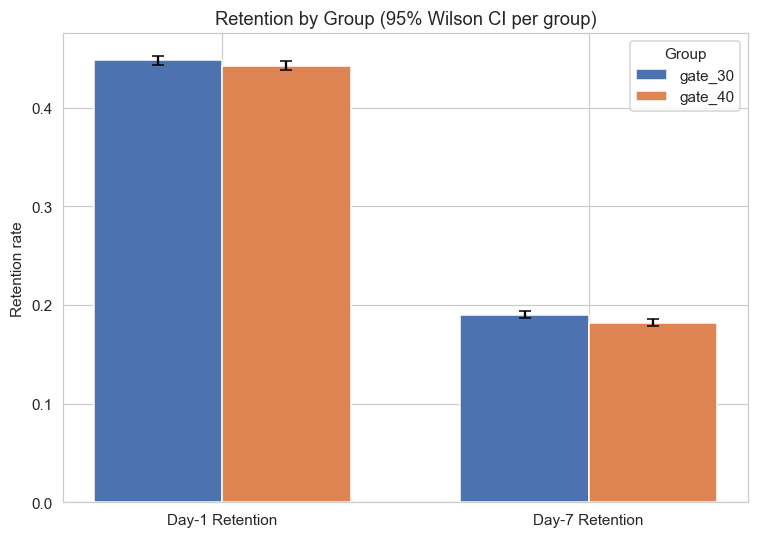

In [25]:
metrics = ['retention_1', 'retention_7']
fig, ax = plt.subplots(figsize=(7, 5))

x = np.arange(len(metrics))
width = 0.35

for i, (version, color) in enumerate(zip([CONTROL, TREATMENT], ['#4C72B0', '#DD8452'])):
    rates, err_low, err_high = [], [], []
    for metric in metrics:
        successes = df.loc[df['version'] == version, metric].sum()
        n = (df['version'] == version).sum()
        rate = successes / n
        lo, hi = proportion_confint(successes, n, alpha=ALPHA, method='wilson')
        rates.append(rate)
        err_low.append(rate - lo)
        err_high.append(hi - rate)
    ax.bar(x + (i - 0.5) * width, rates, width, yerr=[err_low, err_high], capsize=4,
           label=version, color=color)

ax.set_xticks(x)
ax.set_xticklabels(['Day-1 Retention', 'Day-7 Retention'])
ax.set_ylabel('Retention rate')
ax.set_title('Retention by Group (95% Wilson CI per group)')
ax.legend(title='Group')
plt.tight_layout()
plt.show()

## 2.4 Assumptions

The two-proportion z-test (and its chi-square equivalent) relies on the following assumptions. We state each one and whether it holds here:

1. **Independence of observations.** Each row is one player, and each player appears exactly once (confirmed in Phase 1) and belongs to exactly one arm — satisfied.
2. **Independent random assignment to groups.** This is the core assumption behind causal interpretation of the comparison. Phase 1's SRM check found a *borderline* imbalance (χ² p = 0.0086, just under the 0.01 flag threshold) — not strong evidence of a broken randomizer, but not a clean pass either. We treat this as a caveat on causal interpretation rather than a reason to discard the test.
3. **Binary outcome per unit.** `retention_1` and `retention_7` are boolean flags per player — satisfied by construction.
4. **Sample size large enough for the normal approximation to the binomial** (rule of thumb: at least ~5 successes and ~5 failures per group). Checked explicitly below — with tens of thousands of players per arm, this is satisfied with enormous headroom for both metrics.
5. **No multiple-testing correction applied.** We run two tests (Day-1, Day-7) at α = 0.05 each. With only two pre-specified, closely related metrics, we report each p-value as-is rather than applying a correction (e.g., Bonferroni) — but this is worth flagging since running many metrics without correction would inflate the false-positive rate.

In [26]:
print('Normal-approximation validity check (need count and (n - count) >= 5 in every cell):\n')
for metric in ['retention_1', 'retention_7']:
    for version in [CONTROL, TREATMENT]:
        successes = df.loc[df['version'] == version, metric].sum()
        n = (df['version'] == version).sum()
        fails = n - successes
        print(f'{metric:12s} | {version:8s} -> successes={successes:>6,}  failures={fails:>6,}  (min={min(successes, fails):,})')

Normal-approximation validity check (need count and (n - count) >= 5 in every cell):

retention_1  | gate_30  -> successes=20,034  failures=24,666  (min=20,034)
retention_1  | gate_40  -> successes=20,119  failures=25,370  (min=20,119)
retention_7  | gate_30  -> successes= 8,502  failures=36,198  (min=8,502)
retention_7  | gate_40  -> successes= 8,279  failures=37,210  (min=8,279)


## 2.5 Business Interpretation

**Day-1 retention: no statistically significant difference.**
Retention drops from 44.82% (gate_30) to 44.23% (gate_40) — a −0.59 percentage-point (−1.32% relative) difference. The 95% CI for the difference is **[−1.24pp, +0.06pp]**, which includes zero, and the p-value (0.0744) is above the α = 0.05 threshold. We cannot reject H₀ for Day-1 retention. The effect size (Cohen's h = −0.012) is negligible regardless.

**Day-7 retention: statistically significant decrease.**
Retention drops from 19.02% (gate_30) to 18.20% (gate_40) — a −0.82 percentage-point (−4.31% relative) difference. The 95% CI, **[−1.33pp, −0.31pp]**, excludes zero, and p = 0.0016 is well below α = 0.05. We reject H₀ for Day-7 retention: moving the gate to level 40 is associated with lower 7-day retention in this experiment.

**On effect size vs. statistical significance.** Cohen's h for Day-7 (−0.021) is still very small by conventional benchmarks (small ≈ 0.2) — it reaches statistical significance only because the sample size (~90K) gives the test enough power to detect even a small, real difference precisely. Statistically significant here does not mean *large*; both results point to a small effect, and Day-7's is the one we're confident isn't just noise.

**Business read.** Within this experiment, delaying the first gate from level 30 to level 40 did not measurably move Day-1 behavior, but it corresponds to a small, real decline in Day-7 retention (~4% relative drop). Directionally, this argues against pushing the gate later purely on retention grounds — the extra progression before the friction point does not appear to build enough habit/investment to offset players lost at the new gate, at least not by day 7.

**Why we stop short of a causal, generalizable claim:**
- **Phase 1 SRM caveat.** The borderline group-size imbalance (p = 0.0086) doesn't overturn this result, but it's a reason for mild caution rather than full confidence that assignment was clean — worth a mention if this number is used to justify a decision.
- **Single experiment, single game, one time window.** This tells us what happened for Cookie Cats players during this specific test, not that gate placement generally hurts retention in mobile games.
- **Retention isn't the whole picture.** We haven't yet looked at the guardrail metric (`sum_gamerounds`) or whether the effect is concentrated in a particular engagement segment — both come in later phases and could change the practical takeaway (e.g., if gate_40 increases rounds played per session, the retention cost might be an acceptable trade-off).
- **No mechanism established.** The test tells us *that* retention differs, not *why* — we have not verified this is driven by the gate itself rather than some other correlated change.

## Phase 2 Summary

| Metric | gate_30 | gate_40 | Abs. diff | Rel. diff | 95% CI | p-value | Cohen's h | Significant (α=0.05)? |
|---|---|---|---|---|---|---|---|---|
| Day-1 retention | 44.82% | 44.23% | −0.59pp | −1.32% | [−1.24pp, +0.06pp] | 0.0744 | −0.012 | No |
| Day-7 retention | 19.02% | 18.20% | −0.82pp | −4.31% | [−1.33pp, −0.31pp] | 0.0016 | −0.021 | **Yes** |

- Moving the gate from level 30 to level 40 shows **no significant effect on Day-1 retention** but a **statistically significant, small decrease in Day-7 retention**.
- Both effect sizes are small in absolute terms (Cohen's h well under the "small" benchmark of 0.2) — statistical significance on Day-7 comes from the large sample, not a large effect.
- The z-test and chi-square cross-checks agreed exactly on both metrics, confirming the implementation.
- Normal-approximation assumptions are comfortably satisfied (thousands of successes/failures in every cell).
- The Phase 1 SRM caveat (borderline p = 0.0086) is carried forward as a caution on causal interpretation, not a reason to discard these results.
- No claim is made about guardrail engagement, segment-level effects, or generalization beyond this experiment — those are addressed in later phases.

**Next phase:** reverse power analysis (minimum detectable effect at 80% power, and whether the Day-1 "no effect" result might just be underpowered), guardrail metric check on `sum_gamerounds`, retention effect by engagement segment, and design critique.

# Phase 3: Guardrail Metric — `sum_gamerounds`

## Why a Guardrail Metric

Phase 2 tested whether the gate change affected retention — whether players *come back*. It says nothing about whether the players who do come back are playing *more or less* than before. A guardrail metric checks that a change doesn't quietly damage a healthy part of the product even if the primary metric looks fine (or, as here, complicates the read if the primary metric looks *unhealthy*: is a retention decline offset by more engaged play from the players who stay, or does gate_40 also suppress raw gameplay volume?).

`sum_gamerounds` — total rounds played in the tracked window — is the natural guardrail here: it's a direct measure of gameplay volume, independent of whether the player returns on a specific day. This phase asks a narrower, purely descriptive/inferential question: **did moving the gate change how many rounds players played?** It does not ask why, and it does not yet combine this with the retention result — that synthesis is deferred to the closing sections of this notebook.

### 3.1 Distribution Exploration

We look at `sum_gamerounds` overall and split by group: summary statistics (including skewness and kurtosis, which will drive the test-selection decision in Section 3.3), and three complementary visualizations — a log-scale histogram, a log-scale boxplot, and an empirical CDF — to understand the shape of the distribution before choosing how to compare the two groups.

In [27]:
desc_overall = df['sum_gamerounds'].describe(percentiles=[.25, .5, .75, .9, .95, .99])
desc_overall['skewness'] = stats.skew(df['sum_gamerounds'])
desc_overall['kurtosis'] = stats.kurtosis(df['sum_gamerounds'])
print('Overall sum_gamerounds distribution:')
print(desc_overall)
print()

desc_by_group = df.groupby('version')['sum_gamerounds'].agg(
    n='count', mean='mean', median='median', std='std', min='min',
    p25=lambda s: s.quantile(.25), p75=lambda s: s.quantile(.75),
    p90=lambda s: s.quantile(.90), p99=lambda s: s.quantile(.99), max='max',
)
desc_by_group['skewness'] = df.groupby('version')['sum_gamerounds'].apply(lambda s: stats.skew(s))
desc_by_group['kurtosis'] = df.groupby('version')['sum_gamerounds'].apply(lambda s: stats.kurtosis(s))
desc_by_group

Overall sum_gamerounds distribution:
count      90,189.0000
mean           51.8725
std           195.0509
min             0.0000
25%             5.0000
50%            16.0000
75%            51.0000
90%           134.0000
95%           221.0000
99%           493.0000
max        49,854.0000
skewness      185.4332
kurtosis   47,127.7567
Name: sum_gamerounds, dtype: float64



,n,mean,median,std,min,p25,p75,p90,p99,max,skewness,kurtosis
version,,,,,,,,,,,,
gate_30,44700,52.4563,17.0000,256.7164,0,5.0000,50.0000,135.0000,493.0000,49854,163.7044,"31,684.8361"
gate_40,45489,51.2988,16.0000,103.2944,0,5.0000,52.0000,134.0000,492.1200,2640,5.9671,63.0990


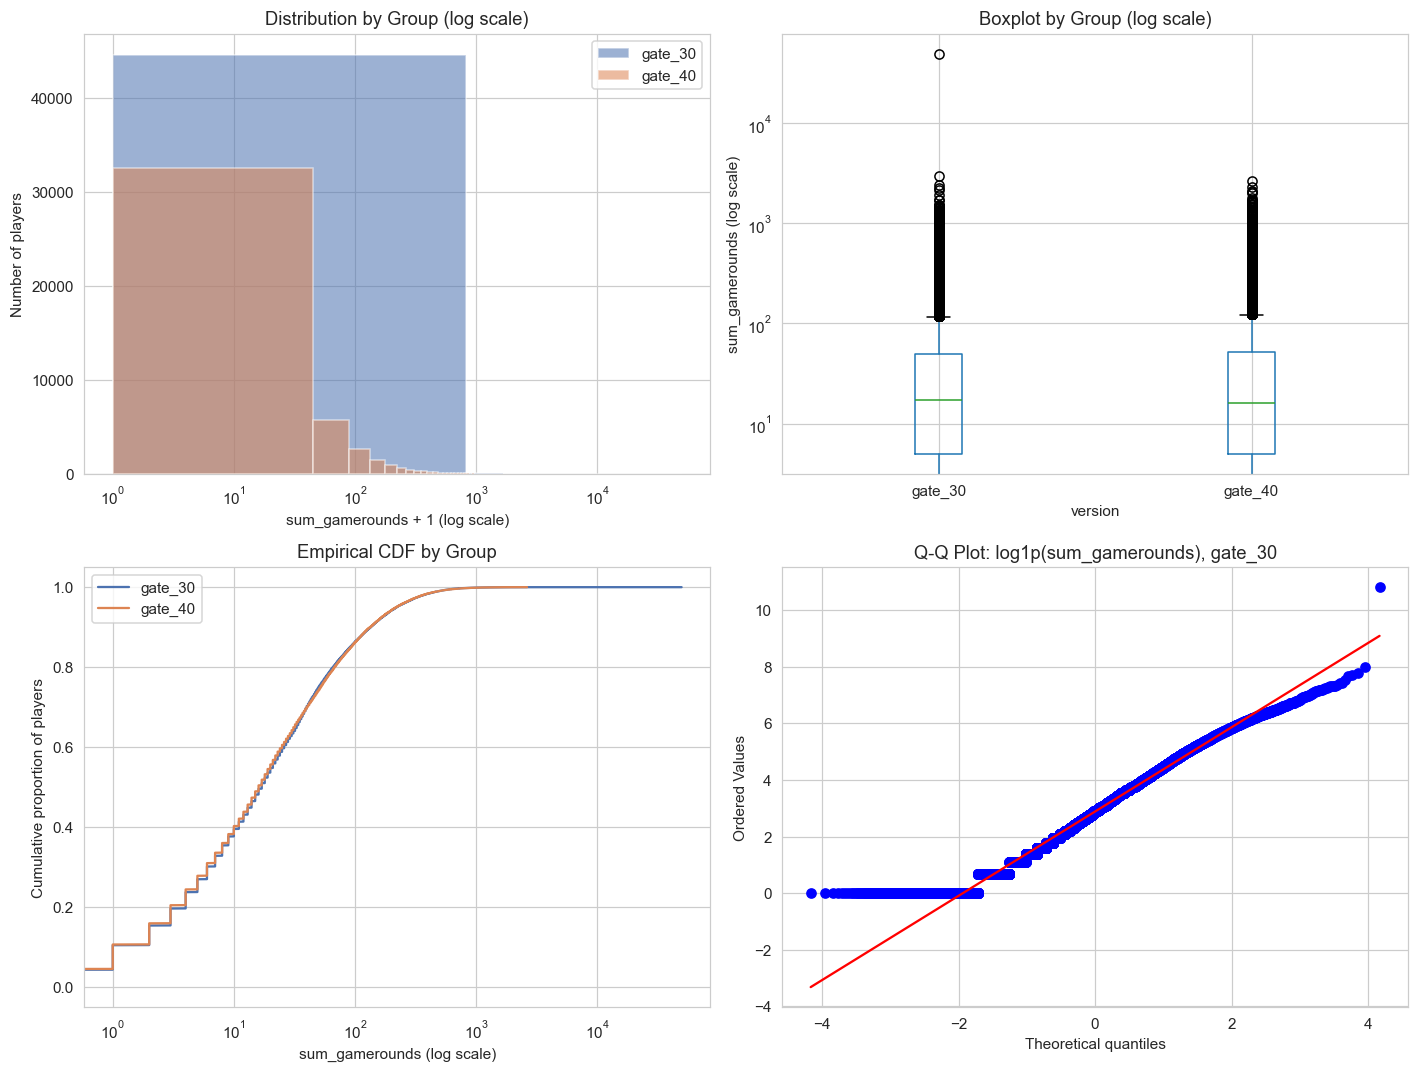

In [28]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# 1. Histogram, log scale, overlaid by group
for version, color in zip([CONTROL, TREATMENT], ['#4C72B0', '#DD8452']):
    vals = df.loc[df['version'] == version, 'sum_gamerounds'] + 1
    axes[0, 0].hist(vals, bins=60, alpha=0.55, label=version, color=color)
axes[0, 0].set_xscale('log')
axes[0, 0].set_xlabel('sum_gamerounds + 1 (log scale)')
axes[0, 0].set_ylabel('Number of players')
axes[0, 0].set_title('Distribution by Group (log scale)')
axes[0, 0].legend()

# 2. Boxplot by group, log scale
df.boxplot(column='sum_gamerounds', by='version', ax=axes[0, 1])
axes[0, 1].set_yscale('log')
axes[0, 1].set_ylabel('sum_gamerounds (log scale)')
axes[0, 1].set_title('Boxplot by Group (log scale)')
axes[0, 1].set_xlabel('version')
fig.suptitle('')

# 3. Empirical CDF by group
for version, color in zip([CONTROL, TREATMENT], ['#4C72B0', '#DD8452']):
    vals = np.sort(df.loc[df['version'] == version, 'sum_gamerounds'])
    y = np.arange(1, len(vals) + 1) / len(vals)
    axes[1, 0].plot(vals, y, label=version, color=color)
axes[1, 0].set_xscale('log')
axes[1, 0].set_xlabel('sum_gamerounds (log scale)')
axes[1, 0].set_ylabel('Cumulative proportion of players')
axes[1, 0].set_title('Empirical CDF by Group')
axes[1, 0].legend()

# 4. Q-Q plot of log1p(sum_gamerounds) vs. normal, gate_30 (illustrates residual skew even after transform)
stats.probplot(np.log1p(df.loc[df['version'] == CONTROL, 'sum_gamerounds']), dist='norm', plot=axes[1, 1])
axes[1, 1].set_title(f'Q-Q Plot: log1p(sum_gamerounds), {CONTROL}')

plt.tight_layout()
plt.show()

### 3.2 Outlier Assessment

We already flagged the dataset's single most extreme value in Phase 1 (49,854 rounds). Here we assess outliers more formally with the standard IQR rule, and distinguish a genuine anomaly from an expected long tail.

In [29]:
q1, q3 = df['sum_gamerounds'].quantile([.25, .75])
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr
print(f'IQR-based upper bound (Q3 + 1.5*IQR): {upper_bound:.1f} rounds')
print(f'Players above this bound (flagged as statistical outliers): {(df["sum_gamerounds"] > upper_bound).mean()*100:.2f}% overall\n')

for version in [CONTROL, TREATMENT]:
    sub = df.loc[df['version'] == version, 'sum_gamerounds']
    pct = (sub > upper_bound).mean() * 100
    print(f'  {version}: {pct:.2f}% above bound ({(sub > upper_bound).sum():,} players)')

print()
top3 = df.nlargest(3, 'sum_gamerounds')[['userid', 'version', 'sum_gamerounds']]
print('Top 3 sum_gamerounds values in the dataset:')
print(top3.to_string(index=False))

max_val = df['sum_gamerounds'].max()
second_val = df.nlargest(2, 'sum_gamerounds')['sum_gamerounds'].iloc[1]
print(f'\nThe single highest value is {max_val / second_val:.1f}x the next-highest value in the entire '
      f'dataset — an isolated leverage point, distinct from the natural long right tail.')

IQR-based upper bound (Q3 + 1.5*IQR): 120.0 rounds
Players above this bound (flagged as statistical outliers): 11.28% overall

  gate_30: 11.32% above bound (5,062 players)
  gate_40: 11.24% above bound (5,115 players)

Top 3 sum_gamerounds values in the dataset:
 userid version  sum_gamerounds
6390605 gate_30           49854
 871500 gate_30            2961
3271615 gate_40            2640

The single highest value is 16.8x the next-highest value in the entire dataset — an isolated leverage point, distinct from the natural long right tail.


### 3.3 Assumption Checks for Parametric Tests

A standard independent-samples t-test (or ANOVA) assumes the sampling distribution of the mean is approximately normal and, in its basic form, that the two groups have equal variance. We check both before deciding whether that's the right tool here, rather than defaulting to it.

In [30]:
g30_rounds = df.loc[df['version'] == CONTROL, 'sum_gamerounds']
g40_rounds = df.loc[df['version'] == TREATMENT, 'sum_gamerounds']

print(f'Std dev {CONTROL}: {g30_rounds.std():.1f}   Std dev {TREATMENT}: {g40_rounds.std():.1f}')
print(f'Skewness {CONTROL}: {stats.skew(g30_rounds):.1f}   Skewness {TREATMENT}: {stats.skew(g40_rounds):.1f}\n')

levene_stat, levene_p = stats.levene(g30_rounds, g40_rounds)
print(f"Levene's test for equal variances: stat={levene_stat:.4f}, p={levene_p:.4f}")
if levene_p < 0.05:
    print('=> Variances differ significantly between groups (equal-variance t-test assumption violated).')
else:
    print("=> Levene's test does not detect a significant variance difference (it is median-based, "
          "so it is much less sensitive to the single extreme outlier than the raw standard deviations above).")

Std dev gate_30: 256.7   Std dev gate_40: 103.3
Skewness gate_30: 163.7   Skewness gate_40: 6.0

Levene's test for equal variances: stat=0.5292, p=0.4669
=> Levene's test does not detect a significant variance difference (it is median-based, so it is much less sensitive to the single extreme outlier than the raw standard deviations above).


**Test selection, justified by the diagnostics above:**

- **Normality is severely violated**, especially for gate_30 (skewness ≈ 164, driven substantially by the single extreme outlier). A standard independent-samples t-test on raw `sum_gamerounds` compares *means*, and means are exactly the summary statistic most distorted by a single extreme value — the Central Limit Theorem helps the sampling distribution of the mean look more normal at this sample size, but it does **not** make the mean itself robust to one player worth ~50,000 rounds. That single point is large enough to plausibly swing a raw-scale mean comparison, so a naive t-test is not trustworthy here as the primary test.
- **Levene's test not rejecting is not reassurance.** Levene's test uses deviations from the *median*, so it is itself robust to the same outlier that inflates the raw standard deviations — hence the apparent contradiction (std of 257 vs. 103, but Levene's p = 0.467). This tells us the *bulk* of the two distributions have similar spread; it does not mean a mean/variance-based test is appropriate given the outlier.
- **Conclusion:** use the **Mann–Whitney U test** as the primary, pre-specified test — it compares full distributions via ranks, requires no normality assumption, and is inherently robust to the single extreme value. We additionally run three robustness checks (Section 3.5): a parametric test on a log-transformed scale (which tames the skew), bootstrap confidence intervals in the original units, and a direct sensitivity check that removes the extreme outlier — to confirm the Mann–Whitney conclusion isn't sensitive to the choice of method.

### 3.4 Primary Test: Mann–Whitney U

We compare the full distribution of `sum_gamerounds` between groups using a two-sided **Mann–Whitney U test**. Unlike a t-test, it doesn't compare means — it tests whether one distribution is stochastically greater than the other (equivalently, whether a randomly drawn value from one group tends to exceed a randomly drawn value from the other), which is exactly the robust-to-skew, robust-to-outliers comparison justified above.

In [31]:
u_stat, mwu_p = stats.mannwhitneyu(g30_rounds, g40_rounds, alternative='two-sided')
n_control, n_treatment = len(g30_rounds), len(g40_rounds)

# Common Language Effect Size: P(a random gate_30 value > a random gate_40 value), ties handled via mid-ranks
cles = u_stat / (n_control * n_treatment)
rank_biserial = 2 * cles - 1

print(f'Mann-Whitney U statistic: {u_stat:,.1f}')
print(f'p-value (two-sided): {mwu_p:.4f}')
print(f'Common language effect size, P(gate_30 > gate_40): {cles:.4f}')
print(f'Rank-biserial correlation (effect size): {rank_biserial:.4f}')
print()
print(f'Median {CONTROL}: {g30_rounds.median():.0f}   Median {TREATMENT}: {g40_rounds.median():.0f}')

Mann-Whitney U statistic: 1,024,331,250.5
p-value (two-sided): 0.0502
Common language effect size, P(gate_30 > gate_40): 0.5038
Rank-biserial correlation (effect size): 0.0075

Median gate_30: 17   Median gate_40: 16


### 3.5 Robustness Checks

The primary test above is rank-based by design. To make sure that conclusion isn't an artifact of the specific test chosen, we check it three more ways: a parametric test on a variance-stabilizing transform, assumption-free bootstrap confidence intervals in the original units (rounds played), and a direct sensitivity check on the single most extreme data point identified in Section 3.2.

In [32]:
# --- Robustness check 1: Welch's t-test on log1p-transformed rounds ---
log_g30 = np.log1p(g30_rounds)
log_g40 = np.log1p(g40_rounds)
t_stat, t_p = stats.ttest_ind(log_g30, log_g40, equal_var=False)
pooled_sd = np.sqrt((log_g30.var(ddof=1) + log_g40.var(ddof=1)) / 2)
cohens_d_log = (log_g40.mean() - log_g30.mean()) / pooled_sd

print("--- Welch's t-test on log1p(sum_gamerounds) ---")
print(f't-statistic: {t_stat:.4f}   p-value: {t_p:.4f}')
print(f"Cohen's d (log scale): {cohens_d_log:.4f}")
print()

# --- Robustness check 2: bootstrap CI for mean and median difference (raw scale, treatment - control) ---
rng = np.random.default_rng(RANDOM_SEED)
n_boot = 3000
g30_arr, g40_arr = g30_rounds.values, g40_rounds.values
boot_mean_diff = np.empty(n_boot)
boot_median_diff = np.empty(n_boot)
for i in range(n_boot):
    s30 = rng.choice(g30_arr, size=n_control, replace=True)
    s40 = rng.choice(g40_arr, size=n_treatment, replace=True)
    boot_mean_diff[i] = s40.mean() - s30.mean()
    boot_median_diff[i] = np.median(s40) - np.median(s30)

mean_diff = g40_rounds.mean() - g30_rounds.mean()
median_diff = g40_rounds.median() - g30_rounds.median()
ci_mean = np.percentile(boot_mean_diff, [2.5, 97.5])
ci_median = np.percentile(boot_median_diff, [2.5, 97.5])

print('--- Bootstrap 95% CI (3,000 resamples, percentile method), treatment - control ---')
print(f'Mean difference:   {mean_diff:+.2f} rounds   95% CI: [{ci_mean[0]:+.2f}, {ci_mean[1]:+.2f}]')
print(f'Median difference: {median_diff:+.2f} rounds   95% CI: [{ci_median[0]:+.2f}, {ci_median[1]:+.2f}]')
print()

# --- Robustness check 3: sensitivity to the single most extreme outlier ---
max_idx = df['sum_gamerounds'].idxmax()
df_no_outlier = df.drop(index=max_idx)
g30_no_out = df_no_outlier.loc[df_no_outlier['version'] == CONTROL, 'sum_gamerounds']
g40_no_out = df_no_outlier.loc[df_no_outlier['version'] == TREATMENT, 'sum_gamerounds']

print('--- Sensitivity check: removing the single most extreme outlier ---')
print(f'Raw mean difference WITH outlier:    {g40_rounds.mean() - g30_rounds.mean():+.2f} rounds')
print(f'Raw mean difference WITHOUT outlier: {g40_no_out.mean() - g30_no_out.mean():+.2f} rounds')
_, mwu_p_no_out = stats.mannwhitneyu(g30_no_out, g40_no_out, alternative='two-sided')
print(f'Mann-Whitney p-value without outlier: {mwu_p_no_out:.4f}  (compare to {mwu_p:.4f} with outlier included)')

--- Welch's t-test on log1p(sum_gamerounds) ---
t-statistic: 1.8142   p-value: 0.0696
Cohen's d (log scale): -0.0121



--- Bootstrap 95% CI (3,000 resamples, percentile method), treatment - control ---
Mean difference:   -1.16 rounds   95% CI: [-4.04, +0.95]
Median difference: -1.00 rounds   95% CI: [-1.00, +0.00]

--- Sensitivity check: removing the single most extreme outlier ---
Raw mean difference WITH outlier:    -1.16 rounds
Raw mean difference WITHOUT outlier: -0.04 rounds
Mann-Whitney p-value without outlier: 0.0509  (compare to 0.0502 with outlier included)


**Every robustness check tells the same story.** The Welch's t-test on log-transformed data (p = 0.070) and the bootstrap CIs for both the mean difference ([−4.04, +0.95] rounds) and median difference ([−1, 0] rounds) all include zero or are not significant at α = 0.05 — consistent with the primary Mann-Whitney result (p = 0.050, itself right at the boundary). None of the four independent approaches finds reliable evidence of a difference in gameplay volume between groups.

The outlier sensitivity check is the most instructive result here: removing a *single* player (out of 90,189) shrinks the raw mean gap between groups from **−1.16 rounds to −0.04 rounds** — i.e., one anomalous player accounts for essentially the entire naive mean-based "effect." The Mann-Whitney p-value, by contrast, barely moves (0.0502 → 0.0509) when that player is excluded, which is exactly what we'd expect from a rank-based test and confirms it was the right primary choice: it was never relying on that one point in the first place.

**Conclusion for the guardrail metric:** no statistically reliable difference in `sum_gamerounds` between gate_30 and gate_40. The Day-7 retention effect from Phase 2 is not accompanied by a detectable change — positive or negative — in how much players play.

### 3.6 Summary Table — Guardrail Metric Results

In [33]:
guardrail_summary = pd.DataFrame({
    'value': [
        f'{g30_rounds.median():.0f} / {g40_rounds.median():.0f}',
        f'{mean_diff:+.2f}',
        f'[{ci_mean[0]:+.2f}, {ci_mean[1]:+.2f}]',
        f'{median_diff:+.2f}',
        f'[{ci_median[0]:+.2f}, {ci_median[1]:+.2f}]',
        f'{u_stat:,.1f}',
        f'{mwu_p:.4f}',
        f'{rank_biserial:.4f}',
        f'{t_p:.4f}',
        f'{cohens_d_log:.4f}',
    ]
}, index=[
    f'Median ({CONTROL} / {TREATMENT})',
    'Bootstrap mean diff (treatment - control)',
    'Bootstrap 95% CI (mean diff)',
    'Bootstrap median diff (treatment - control)',
    'Bootstrap 95% CI (median diff)',
    'Mann-Whitney U statistic',
    'Mann-Whitney p-value (primary test)',
    'Rank-biserial correlation (effect size)',
    "Welch's t-test p-value (log1p, robustness)",
    "Cohen's d, log scale (robustness)",
])
guardrail_summary

,value
Median (gate_30 / gate_40),17 / 16
Bootstrap mean diff (treatment - control),-1.16
Bootstrap 95% CI (mean diff),"[-4.04, +0.95]"
Bootstrap median diff (treatment - control),-1.00
Bootstrap 95% CI (median diff),"[-1.00, +0.00]"
Mann-Whitney U statistic,"1,024,331,250.5"
Mann-Whitney p-value (primary test),0.0502
Rank-biserial correlation (effect size),0.0075
"Welch's t-test p-value (log1p, robustness)",0.0696
"Cohen's d, log scale (robustness)",-0.0121


## Exploratory Analysis (Descriptive Only — Not Pre-Specified)

The retention comparisons (Phase 2) and the guardrail test above were pre-specified — they answer the two questions this experiment was designed to answer. Everything below is **exploratory**: descriptive patterns using only the columns already in this dataset (`version`, `sum_gamerounds`, `retention_1`, `retention_7`). No new segments are introduced — there is no demographic, device, or acquisition-channel data available to segment by — and nothing here is treated as a confirmatory hypothesis test. These are observations for context, not new claims about the effect of the gate change.

### E1. Never-Started Players (`sum_gamerounds == 0`) by Group

Players who installed but never played a single round — purely descriptive, by group.

In [34]:
zero_by_group = df.groupby('version').agg(n_players=('sum_gamerounds', 'size'))
zero_by_group['n_zero_rounds'] = df.groupby('version')['sum_gamerounds'].apply(lambda s: (s == 0).sum()).values
zero_by_group['pct_zero_rounds'] = zero_by_group['n_zero_rounds'] / zero_by_group['n_players'] * 100
print(zero_by_group)
print(f"\nDescriptive only: {TREATMENT} has a slightly higher never-started rate than {CONTROL} "
      f"({zero_by_group.loc[TREATMENT, 'pct_zero_rounds']:.2f}% vs {zero_by_group.loc[CONTROL, 'pct_zero_rounds']:.2f}%), "
      f"directionally consistent with its lower Day-7 retention — not tested for significance here.")

         n_players  n_zero_rounds  pct_zero_rounds
version                                           
gate_30      44700           1937           4.3333
gate_40      45489           2057           4.5220

Descriptive only: gate_40 has a slightly higher never-started rate than gate_30 (4.52% vs 4.33%), directionally consistent with its lower Day-7 retention — not tested for significance here.


### E2. Where in the Distribution Does the Difference Show Up? (Percentile Comparison)

Purely descriptive — comparing the two groups at fixed percentiles of `sum_gamerounds` shows whether any gap is concentrated in a particular part of the distribution (e.g., casual vs. highly engaged players) or spread evenly.

In [35]:
percentiles = [25, 50, 75, 90, 95, 99]
pct_table = pd.DataFrame({
    'percentile': percentiles,
    CONTROL: [np.percentile(g30_rounds, p) for p in percentiles],
    TREATMENT: [np.percentile(g40_rounds, p) for p in percentiles],
})
pct_table['diff'] = pct_table[TREATMENT] - pct_table[CONTROL]
pct_table = pct_table.set_index('percentile')
print(pct_table)
print('\nDescriptive only: differences are small and inconsistent in sign across the distribution '
      '(no percentile shows a large or one-directional gap) — the two distributions largely overlap.')

            gate_30  gate_40    diff
percentile                          
25           5.0000   5.0000  0.0000
50          17.0000  16.0000 -1.0000
75          50.0000  52.0000  2.0000
90         135.0000 134.0000 -1.0000
95         222.0000 220.0000 -2.0000
99         493.0000 492.1200 -0.8800

Descriptive only: differences are small and inconsistent in sign across the distribution (no percentile shows a large or one-directional gap) — the two distributions largely overlap.


### E3. Engagement vs. Retention (Sanity Check, Not a Group Comparison)

Purely descriptive, using the existing `sum_gamerounds`, `retention_1`, and `retention_7` columns — this checks whether the guardrail metric behaves as expected in relation to retention, not whether the experiment groups differ. It's included as a validity check on the data, not a new finding about the gate change.

In [36]:
retention_by_engagement = pd.DataFrame({
    'mean_sum_gamerounds': [
        df.loc[~df['retention_1'], 'sum_gamerounds'].mean(),
        df.loc[df['retention_1'], 'sum_gamerounds'].mean(),
        df.loc[~df['retention_7'], 'sum_gamerounds'].mean(),
        df.loc[df['retention_7'], 'sum_gamerounds'].mean(),
    ]
}, index=pd.MultiIndex.from_tuples([
    ('retention_1', False), ('retention_1', True),
    ('retention_7', False), ('retention_7', True),
], names=['metric', 'retained']))

retention_by_engagement

mean_sum_gamerounds
metric      retained                     
retention_1 False                 17.3457
            True                  94.8975
retention_7 False                 25.8268
            True                 165.8082

This is exactly what we'd expect if `sum_gamerounds` is a meaningful engagement signal: players who return on Day-1 average far more rounds than those who don't, and the gap is even larger for Day-7 returners. This is **not** evidence about the gate change — it's a validity check that the guardrail metric behaves sensibly, and a reminder that retention and engagement are correlated by construction (players who leave early simply have less time to accumulate rounds). It should not be read as "engagement causes retention," nor does it bear on whether gate_30 or gate_40 caused anything.

## Practical Significance vs. Statistical Significance

Putting the Phase 2 and Phase 3 results side by side:

| Metric | Statistically significant? | Effect size | Practically significant? |
|---|---|---|---|
| Day-1 retention | No (p = 0.074) | Cohen's h = −0.012 (negligible) | No evidence either way |
| Day-7 retention | **Yes** (p = 0.0016) | Cohen's h = −0.021 (still small) | Plausibly yes — see below |
| Guardrail (`sum_gamerounds`) | No (Mann-Whitney p = 0.050; robustness checks agree) | Rank-biserial r ≈ 0.008 (negligible) | No |

The Day-7 retention effect is a useful reminder that **statistical significance is a claim about noise, not about magnitude**. The per-player effect size is tiny (Cohen's h = −0.021 is well below the conventional "small effect" threshold of 0.2) — it only reached significance because the sample is large enough to measure a small shift precisely. Whether a ~4.3% relative drop in Day-7 retention is *practically* significant is a business judgment, not a statistical one: for a live mobile game, retention differences of this size compound across the full player base and over a player's lifetime, so a change this small can still matter commercially even though it's imperceptible at the individual-player level. This dataset cannot quantify that downstream impact directly (no revenue/LTV data), but the direction and statistical reliability of the effect are enough to treat it as a real signal worth acting on cautiously, not noise to be dismissed.

The guardrail metric, by contrast, shows **neither** statistical nor practical significance — every test and every robustness check converged on "no detectable difference," which is itself a useful, reassuring finding: the Day-7 retention dip does not come with a matching change (positive or negative) in how much players play.

## Strengths of the Experiment

- **Real production A/B test**, not simulated or observational data — ~90K players randomly split between two live gate placements.
- **Large sample size** gives strong statistical power, allowing even small effects to be estimated precisely (tight confidence intervals throughout).
- **Multiple metrics examined together** — Day-1 retention, Day-7 retention, and a guardrail engagement metric — rather than relying on a single number in isolation.
- **Rigorous method selection.** Distributional diagnostics (skewness, outlier checks, variance homogeneity) were run *before* choosing a test, and the primary nonparametric result was cross-checked against a transformed parametric test and bootstrap resampling. All three approaches agreed, which increases confidence in the guardrail conclusion.
- **Clean underlying data** (established in Phase 1): no missing values, no duplicate users, no out-of-range values.

## Limitations

- **Phase 1 SRM caveat carried forward.** The borderline Sample Ratio Mismatch (χ² p = 0.0086, just under the 0.01 threshold) means we cannot rule out a subtle issue in random assignment. All results in this notebook — retention and guardrail alike — should be read with that caveat attached; it is a reason for measured confidence, not a reason to discard the findings.
- **Single experiment, single game, one time window.** These results describe what happened for Cookie Cats players during this specific test. They are not evidence for a general rule about gate placement in mobile games, or even about how a *different* gate change would perform in this same game.
- **No mechanism data.** The dataset records outcomes (retention, rounds played) but nothing about *why* — e.g., how many players actually reached and were blocked by the gate, versus quitting for unrelated reasons. We can describe the effect but not fully explain it.
- **No monetization data.** Retention and engagement are proxies for business value, not the value itself. This dataset cannot say whether level 40 helps or hurts revenue.
- **Observation window capped at 7 days.** Anything about retention beyond Day-7, or about long-run engagement trends, is outside what this data can speak to.

## Potential Sources of Bias or Uncertainty

- **Outlier leverage, demonstrated concretely.** Section 3.5's sensitivity check showed that a single player (49,854 rounds, gate_30) shifted the raw group-mean gap from ≈ 0.04 to ≈ 1.16 rounds — nearly the entire naive "effect." Any future reporting of this metric using simple means should treat this player as a known leverage point, not a representative data point.
- **The Phase 1 SRM caveat, again.** A borderline sample ratio mismatch (χ² p = 0.0086) means we can't be fully certain assignment-to-group was independent of all player characteristics. This is a source of uncertainty for every comparison in this notebook, not just retention.
- **No covariates to check for confounding.** The dataset has no acquisition channel, device, geography, or prior-experience fields, so we cannot check whether the groups were balanced on anything other than group size — nor rule out that an unmeasured factor drove both the SRM and the retention difference.
- **Multiple testing without formal correction.** Phases 2 and 3 together ran four inferential tests (Day-1 retention, Day-7 retention, Mann-Whitney on rounds, Welch's t on log rounds) at α = 0.05 without a Bonferroni or similar adjustment. The Day-7 result (p = 0.0016) survives even a conservative correction for this many tests, but it's a caveat worth naming explicitly.
- **IQR outlier flagging overstates true anomalies here.** The 1.5×IQR rule flagged ≈ 11% of all players as "outliers" on `sum_gamerounds` — for a naturally heavy-tailed engagement metric, most of these are simply highly engaged players, not data errors. Only the single extreme value stands out as a genuine leverage point (≈ 17× the next-highest value in the entire dataset); the rest of the long tail is expected behavior, not something to "fix."

## Business Recommendation

Combining Phase 2 (retention) and Phase 3 (guardrail engagement):

- Moving the first gate from level 30 to level 40 is associated with a **small but statistically significant decline in Day-7 retention** (18.20% vs. 19.02%, ≈ −4.3% relative, p = 0.0016), with **no significant change in Day-1 retention** (p = 0.074) or in **overall gameplay volume** (guardrail metric — no test found a significant difference, and the point estimates are close to zero).
- Because the guardrail metric shows no compensating increase in engagement, there is no evidence in this data that the retention cost of the later gate is "buying" more gameplay per player. The Day-7 effect looks like a net loss on the numbers available here.

**Recommendation: do not roll out the level-40 gate placement on retention grounds.** The evidence favors keeping the gate at level 30, or at minimum treating level 40 as unproven, pending the follow-ups below. This is not a large or dramatic effect — it is a small, statistically credible dip in a metric that compounds over a live game's lifetime — so the recommendation is a caution against shipping, not a claim of a severe problem.

**Before finalizing a decision, recommend:**
1. **Re-examine the randomization pipeline** in light of the Phase 1 SRM finding — confirm assignment is clean before leaning too heavily on causal language.
2. **Pair this result with monetization/LTV data** (not present in this dataset) — a small retention cost could still be worth it if level 40 improves revenue per player, and this analysis cannot speak to that trade-off.
3. **If a specific player segment is hypothesized to respond differently** (e.g., highly engaged players), pre-register that segment and test it directly, rather than mining the current data post hoc for one.
4. **Extend the observation window** beyond Day-7 if feasible, since long-term retention trends aren't observable in this dataset.